# Assignment 8 - k-Nearest Neighbors (kNNs)
(20 points)

### Add your name(s) and EIDs below
- Student Name: Lily Nguyen
- Student UT EID: lmn934
- Partner Name: John "Jack" Mayberry
- Partner UT EID: jmm23398


# k-Nearest Neighbors
For this assignment, we are going explore one new classification technique: k nearest neighbors.

We are using a different version of the Melbourne housing data set from earlier in the semester, split into training and testing sets for you. Our goal is to predict the housing type as one of three possible categories:

  - 'h' house
  - 'u' duplex
  - 't' townhouse

At the end of this homework, you will understand how to build and use a kNN model, and improve your data cleaning and data preparation skills. 

In [3974]:
# These are the libraries you will use for this assignment.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import calendar
%matplotlib inline

In [3975]:
# Start off by loading the training dataset.
df_melb = pd.read_csv('melb_data_train.csv')
df_melb

,Rooms,Type,Price,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt
0,3,t,732000,26/07/2016,5.6,3101,1,1.0,904,110.0,1980.0
1,3,h,1001000,4/3/17,12.6,3020,1,5.0,879,NaN,NaN
2,2,u,605000,7/5/16,7.4,3185,1,1.0,722,NaN,1970.0
3,3,h,757500,17/06/2017,18.8,3170,2,1.0,145,NaN,NaN
4,4,h,721000,16/09/2017,17.9,3082,2,2.0,603,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
970,2,h,2200000,15/10/2016,2.6,3052,2,1.0,190,172.0,1875.0
971,3,u,510000,17/06/2017,12.0,3073,1,1.0,178,100.0,2009.0
972,3,t,1115000,4/3/17,13.9,3165,2,2.0,297,NaN,NaN
973,2,u,722000,12/11/16,9.0,3126,1,1.0,0,92.0,1965.0


## Q1 

**Fix our "Date" column to be numeric**: If we inspect our dataframe `df_melb` using the `dtypes` property, we see that the column `Date` is an `object`.  However, we think this column might contain useful information, so your goal is to convert it to [Unix time](https://en.wikipedia.org/wiki/Unix_time).

Unix time is the number of secconds since a fixed time known as the "Unix epoch", which is midnight on January 1st, 1970. For example, the Unix time for March 10th, 2023 is 1,678,474,369 seconds.

- **Use only the libraries imported above** imported libraries to create a new column `UnixTime`. 
    - Be careful, the date strings in the file might have some non-uniform formatting that you have to fix first.  
- Print out the min and max epoch time to check your work.  
- Drop the original `Date` column. 

The Python [reference for time](https://docs.python.org/3/library/time.html) can help you with your conversion to Unix time.

(**3 points**)

In [3976]:
# For reference, here are the data types of each column.
df_melb.dtypes
df_melb['Date']

0      26/07/2016
1          4/3/17
2          7/5/16
3      17/06/2017
4      16/09/2017
          ...    
970    15/10/2016
971    17/06/2017
972        4/3/17
973      12/11/16
974       10/9/16
Name: Date, Length: 975, dtype: object

<!-- BEGIN QUESTION -->



In [3977]:
def standardize_date(date_string):
    """Standardize a date string to a standard format.

    Rules:
    - You can assume the input string is of the form day/month/year.
    - Fixed date strings should be of the form DD/MM/YYYY. If a day is
      one digit, append zeros.
    - If the input string's year is two digits (e.g. 02), assume
      the year is in the 2000s (e.g. 2002).
    """
    date_string = date_string.split('/')
  
    for i in range(2):
      if len(date_string[i]) != 2:
        date_string[i] = '0' + date_string[i]

    if len(date_string[2]) != 4:
      date_string[2] = '20' + date_string[2]

    return '/'.join(date_string)

def replace_date_with_unix(df):
    """Given a Melbourne dataset dataframe, replace the Date column
    with a UnixTime column.

    Hint: Call standardize_date within this function.
    """
    # Standardize the date column.
    df['Date'] = df['Date'].apply(standardize_date) # modify series

    # Create the UnixTime column
    df['UnixTime'] = df['Date'].apply(date_to_unix)

    # Drop the date column.
    df = df.drop('Date', axis=1)

    return df

# helper function
def date_to_unix(date):
    """ 
    converts string of date to unix datetime format
    """
    return int(time.mktime(datetime.datetime.strptime(date, '%d/%m/%Y').timetuple()))

In [3978]:
df_melb_q1 = replace_date_with_unix(df_melb)

# Print the cleaned UnixTime values.
print('Min UnixTime:', df_melb_q1['UnixTime'].min())
print('Max UnixTime:', df_melb_q1['UnixTime'].max())

Min UnixTime: 1454565600
Max UnixTime: 1506142800


<!-- END QUESTION -->

## Q2 

**Use imputation to fill in missing values**: kNN doesn't work when some attributes are not present, so we must fill in all the missing values in `df_melb` with something. As a simple estimate, we will fill in missing values with the **mean** of that value/column.

What we're trying to classify ('h'ome/'d'u'plex/'t'ownhouse), also knonw as the **target**, is store in the `Type` column. We define a variable `target_col` which lets you automatically infer which column is the target. During imputation, we should skip this target column.

- Use `df_melb_q1`, i.e. the result from Q1.
- Save the mean of each column in a dictionary `dict_imputation`. Keys are an attribute's column name, and values are that attribute's mean.
- Use `dict_imputation` to imputate the missing values in `df_melb_q1`.
- Store the imputated dataframe in `df_melb_q2`.

(**3 points**)

<!-- BEGIN QUESTION -->



In [3979]:
df_melb.isna().sum()

Rooms             0
Type              0
Price             0
Date              0
Distance          0
Postcode          0
Bathroom          0
Car               1
Landsize          0
BuildingArea    478
YearBuilt       388
UnixTime          0
dtype: int64

In [3980]:
def build_imputation_dict(df, target_col):
    """Collect the mean values of each column, excluding NaN values
    and the target column.
    """
    dict_imputation = {}

    # Note: NaN values are ignored in series mean calculation by default
    # means = df.mean(numeric_only=True)

    for col in df.columns:
        if col != target_col:
            mean = df[col].mean()
            dict_imputation[col] = float(mean)

    return dict_imputation

def imputate(df, dict_imputation, target_col):
    """Imputate a dataframe, replacing missing values with those
    given in dict_imputation. Do not imputate target_col."""
    # check for NaN in df
    # use fillna() to replace NaN with means

    new_df = df.copy() # maintain original dataframe the same, might delete later

    for col in new_df.columns:
        if col != target_col:
            new_df[col] = new_df[col].fillna(dict_imputation[col])

    return new_df

In [3981]:
# Define the target column as a string
target_col = 'Type'

# Collect imputation values
dict_imputation = build_imputation_dict(df_melb_q1, target_col)

# Imputate the dataframe
df_melb_q2 = imputate(df_melb_q1, dict_imputation, target_col)

In [3982]:
# Check your results
dict_imputation

{'Rooms': 2.710769230769231,
 'Price': 941972.2953846154,
 'Distance': 10.206256410256408,
 'Postcode': 3110.873846153846,
 'Bathroom': 1.4543589743589744,
 'Car': 1.4938398357289528,
 'Landsize': 514.2184615384615,
 'BuildingArea': 131.379476861167,
 'YearBuilt': 1971.0204429301534,
 'UnixTime': 1485054996.9230769}

In [3983]:
# Check your results
df_melb_q2.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
0,3,t,732000,5.6,3101,1,1.0,904,110.000000,1980.000000,1469509200
1,3,h,1001000,12.6,3020,1,5.0,879,131.379477,1971.020443,1488607200
2,2,u,605000,7.4,3185,1,1.0,722,131.379477,1970.000000,1462597200
3,3,h,757500,18.8,3170,2,1.0,145,131.379477,1971.020443,1497675600
4,4,h,721000,17.9,3082,2,2.0,603,131.379477,1971.020443,1505538000


In [3984]:
# extra: checking to make sure no NaN remaining
df_melb_q2.isna().sum()

Rooms           0
Type            0
Price           0
Distance        0
Postcode        0
Bathroom        0
Car             0
Landsize        0
BuildingArea    0
YearBuilt       0
UnixTime        0
dtype: int64

<!-- END QUESTION -->

## Q3

**Normalize all attributes to be between [0,1]**: Normalize all the attribute columns in `df_melb_q2` so they have a value between zero and one (inclusive). 

To do this, we will build a dictionary `dict_normalize`, with column names for keys and (min, max) tuples for values, which are the min (resp. max) value found in the dataframe for that column. Just like in Q2, we do not normalize the target column.

After creating `dict_normalize`, we will use it to normalize each column and generate a new dataframe, `df_melb_q3`. The resulting dataframe is now your model that you can use to classify new data points.

- Use `df_melb_q2`, i.e. the result from Q2.
- Save the minimum and maximum values of each column in a dictionary `dict_normalize`. Keys are an attribute's column name, and values are a (min, amx) tuple for that column,
- Use `dict_normalize` to normalize the missing values in `df_melb_q2`.
- Store the imputated dataframe in `df_melb_q3`.

(**3 points**)

<!-- BEGIN QUESTION -->



In [3985]:
def build_normalization_dict(df, target_col):
    """Collect the (min, max) values of each column, except the
    target column.
    """
    dict_normalize = {}

    # Get the min and max values of each column.
    for col in df.columns:
        if col != target_col:
            dict_normalize[col] = (df[col].min(), df[col].max())

    return dict_normalize

def normalize(df, dict_normalize, target_col):
    """Normalize a dataframe, setting all values to the range [0, 1]
    using (min, max) values in dict_normalize. Do not normalize target_col."""
    # min-mas normalization
    # normalized_val = (x - x_min) / (x_max - x_min)

    new_df = df.copy() # make copy to not override og df

    for col in new_df.columns:
        if col != target_col:
            x_min, x_max = dict_normalize[col]
            new_df[col] = (new_df[col] - x_min) / (x_max - x_min) # normalize values to [0,1]
            
    return new_df

In [3986]:
# Define the target column as a string
target_col = 'Type'

# Collect normalization values
dict_normalize = build_normalization_dict(df_melb_q2, target_col)

# Normalize the dataframe
df_melb_q3 = normalize(df_melb_q2, dict_normalize, target_col)

In [3987]:
# Check your results
dict_normalize

{'Rooms': (np.int64(1), np.int64(7)),
 'Price': (np.int64(210000), np.int64(5020000)),
 'Distance': (np.float64(0.7), np.float64(47.3)),
 'Postcode': (np.int64(3000), np.int64(3810)),
 'Bathroom': (np.int64(0), np.int64(5)),
 'Car': (np.float64(0.0), np.float64(8.0)),
 'Landsize': (np.int64(0), np.int64(41400)),
 'BuildingArea': (np.float64(0.0), np.float64(3558.0)),
 'YearBuilt': (np.float64(1850.0), np.float64(2016.0)),
 'UnixTime': (np.int64(1454565600), np.int64(1506142800))}

In [3988]:
# Check your results
df_melb_q3.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
0,0.333333,t,0.108524,0.105150,0.124691,0.2,0.125,0.021836,0.030916,0.783133,0.289733
1,0.333333,h,0.164449,0.255365,0.024691,0.2,0.625,0.021232,0.036925,0.729039,0.660013
2,0.166667,u,0.082121,0.143777,0.228395,0.2,0.125,0.017440,0.036925,0.722892,0.155720
3,0.333333,h,0.113825,0.388412,0.209877,0.4,0.125,0.003502,0.036925,0.729039,0.835834
4,0.500000,h,0.106237,0.369099,0.101235,0.4,0.250,0.014565,0.036925,0.729039,0.988274


In [3989]:
# just checking - can remove this cell later
df_melb_q3.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
count,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000
mean,0.285128,0.152177,0.203997,0.136881,0.290872,0.186730,0.012421,0.036925,0.729039,0.591141
std,0.151278,0.108044,0.130650,0.107062,0.123886,0.107432,0.048260,0.033701,0.152258,0.261845
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.081081,0.111588,0.062963,0.200000,0.125000,0.002017,0.030916,0.722892,0.366790
50%,0.333333,0.123701,0.182403,0.127160,0.200000,0.125000,0.007174,0.036925,0.729039,0.648286
75%,0.333333,0.198025,0.266094,0.201235,0.400000,0.250000,0.014855,0.036925,0.783133,0.835834
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<!-- END QUESTION -->

## Q4 

**Prepare the test data**: Load in `melb_data_test.csv` and repeat the steps in Q1, Q2, and Q3 (unix time, imputation, and normalization).

(**1 point**)

<!-- BEGIN QUESTION -->



Question to ask the TA: when making dict_imputation_test and dict_normalize_test, are we supposed to use the training data csv or the test data csv?

In [3990]:
# Load the test dataframe (already loaded train dataframe in Q1-3)
df_melb_test = pd.read_csv('melb_data_test.csv')

# Clean the dates, add unix time
df_melb_test = replace_date_with_unix(df_melb_test)

# Imputate the dataframe
target_col = 'Type'
dict_imputation1 = build_imputation_dict(df_melb_q1, target_col)
df_melb_test = imputate(df_melb_test, dict_imputation1, target_col)

# Normalize the dataframe
dict_normalize1 = build_normalization_dict(df_melb_q2, target_col)
df_melb_test = normalize(df_melb_test, dict_normalize1, target_col)

In [3991]:
# checking train/test ratio -> delete later
print(df_melb_q3.shape)
print(df_melb_test.shape)
print(len(df_melb_test) / (len(df_melb_q3) + len(df_melb_test)))

(975, 11)
(122, 11)
0.11121239744758432


In [3992]:
df_melb_q3.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
count,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000
mean,0.285128,0.152177,0.203997,0.136881,0.290872,0.186730,0.012421,0.036925,0.729039,0.591141
std,0.151278,0.108044,0.130650,0.107062,0.123886,0.107432,0.048260,0.033701,0.152258,0.261845
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.081081,0.111588,0.062963,0.200000,0.125000,0.002017,0.030916,0.722892,0.366790
50%,0.333333,0.123701,0.182403,0.127160,0.200000,0.125000,0.007174,0.036925,0.729039,0.648286
75%,0.333333,0.198025,0.266094,0.201235,0.400000,0.250000,0.014855,0.036925,0.783133,0.835834
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3993]:
df_melb_test.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
count,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000
mean,0.315574,0.168137,0.215243,0.127140,0.298361,0.207992,0.011533,0.039128,0.717369,0.583077
std,0.180306,0.107589,0.135699,0.083557,0.129196,0.136941,0.013140,0.016488,0.153259,0.271972
min,0.000000,0.024532,0.019313,0.013580,0.200000,0.000000,0.000000,0.000843,0.240964,0.000000
25%,0.166667,0.095634,0.131438,0.054938,0.200000,0.125000,0.004064,0.036925,0.722892,0.347526
50%,0.333333,0.143763,0.207082,0.100000,0.200000,0.187500,0.010543,0.036925,0.729039,0.519299
75%,0.333333,0.206367,0.259120,0.184877,0.400000,0.250000,0.015978,0.036925,0.729039,0.829971
max,1.000000,0.548857,0.800429,0.529630,0.600000,0.750000,0.121304,0.142215,0.987952,1.000000


In [3994]:
# Check your results
df_melb_test.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
0,0.166667,t,0.120582,0.225322,0.056790,0.4,0.125,0.005024,0.035694,0.963855,0.835834
1,0.333333,h,0.238046,0.173820,0.088889,0.2,0.250,0.022126,0.036925,0.729039,0.425421
2,0.666667,h,0.540541,0.120172,0.176543,0.4,0.250,0.014903,0.036925,0.729039,0.345013
3,0.333333,h,0.133056,0.210300,0.041975,0.2,0.125,0.014324,0.033165,0.722892,0.355064
4,0.333333,h,0.124740,0.800429,0.245679,0.2,0.250,0.020169,0.033165,0.662651,0.871013


In [3995]:
df_melb_q3.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,UnixTime
0,0.333333,t,0.108524,0.105150,0.124691,0.2,0.125,0.021836,0.030916,0.783133,0.289733
1,0.333333,h,0.164449,0.255365,0.024691,0.2,0.625,0.021232,0.036925,0.729039,0.660013
2,0.166667,u,0.082121,0.143777,0.228395,0.2,0.125,0.017440,0.036925,0.722892,0.155720
3,0.333333,h,0.113825,0.388412,0.209877,0.4,0.125,0.003502,0.036925,0.729039,0.835834
4,0.500000,h,0.106237,0.369099,0.101235,0.4,0.250,0.014565,0.036925,0.729039,0.988274


<!-- END QUESTION -->

## Q5

**Write the kNN classifier function**: Your function, `predict_knn` will take in the following four parameters:
- Training dataframe `df_train`
- Hyperparameter `k`
- Testing sample `test_sample` (one row of the DataFrame, we can generate it using `iloc` or `iterrows`).
- Target column string `target_col`, which defines the variable we want to predict.

It will predict which class `test_sample` belongs to, based on the `k` nearest neighbors to the sample.

- We assume `df_train` is normalized/imputated, contains all attributes, and also contains the target column.
- Likewise, we assume `test_sample` is normalized/imputated and contains all attributes. (But, it does not have to have the target column).

*Hint*: To find the distance between the test sample and any element of the training dataset, you may use the [L2 norm function from numpy](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html).

(**5 points**)

<!-- BEGIN QUESTION -->



In [3996]:
def predict_knn(df_train: pd.DataFrame, k: int, 
                test_sample: pd.Series, target_col: str):
    """Use the k-nearest neighbors algorithm to predict the class of a test-sample,
    given a training set.
    
    Parameters:
        df_train:    DataFrame of training samples
        k:           Number of neighbors to consider
        test_sample: Single evaluation sample
        target_col:  Name of the target variable (column)

    Returns:
        prediction: Predicted class of the test sample using kNN.
    """
    df_train1 = df_train.copy() # prevent overriding df
    # compute L2 euclidean distance between each row in df_train and test_sample, drop target_col
    df_train1['distance'] = df_train1.apply(lambda x : np.linalg.norm(x.drop(index=target_col) - test_sample), axis=1)
    df_train1 = df_train1.sort_values(by='distance').reset_index(drop=True)
    df_k = df_train1[0:k]
    
    prediction = df_k[target_col].value_counts().index[0]
    
    return prediction

<!-- END QUESTION -->

## Q6 

**Compute the accuracy using different k values**: For each value of $k$ in the set $\{1,3,13,25,50,100\}$, compute the kNN prediction for each oberservation in the test set, and the overall accuracy of the classifier.  Plot the accuracy as a function of $k$.

- Use your imputed, normalize training dataframe (`df_melb_q3`).
- Use your imputed, normalized testing dataframe (`df_melb_test`).
- Have an outer loop over the k-values, and an inner loop computing the prediction for each testing sample under that k-value.

Which value of $k$ would you choose? Why?

(This can take a while to run; probably at least 5-10 minutes.)

(**5 points - 3 for implementation, 1 for plot, 1 for description**).

(**This question will be manually graded.**)

<!-- BEGIN QUESTION -->



In [3997]:
# Sweep over the k-values. Place your accuracies for each k-value in acc_k.
poss_k = [1, 3, 13, 25, 50, 100]
acc_k = np.zeros(len(poss_k))

X_test = df_melb_test.copy()
X_train = df_melb_q3.copy()

# Your code goes below.
acc_idx = 0
for k in poss_k:
    # predictions for each test sample
    predictions = X_test.apply( lambda x : predict_knn(X_train.copy(), k, x.drop(index=target_col), target_col), axis=1)

    acc_k[acc_idx] = np.sum(predictions == X_test[target_col]) / len(predictions)
    print(f'k = {k}, Accuracy = {acc_k[acc_idx]}')

    acc_idx = acc_idx + 1

k = 1, Accuracy = 0.7540983606557377
k = 3, Accuracy = 0.7540983606557377
k = 13, Accuracy = 0.7786885245901639
k = 25, Accuracy = 0.7868852459016393
k = 50, Accuracy = 0.7622950819672131
k = 100, Accuracy = 0.7213114754098361


Most optimal k is 25 with Accuracy = 0.7869


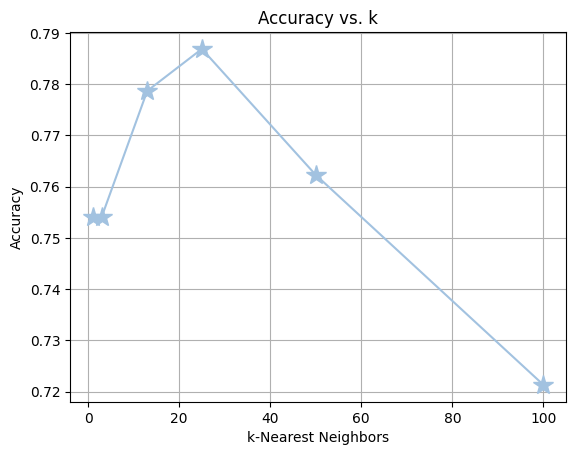

In [3998]:
print(f'Most optimal k is {poss_k[np.argmax(acc_k)]} with Accuracy = {float(max(acc_k)):.4f}')

# Plot your accuracies for each k-value.
plt.plot(poss_k, acc_k, marker='*', linestyle='-', color='#A2C2E0', markersize=15)
plt.title('Accuracy vs. k')
plt.xlabel('k-Nearest Neighbors')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

At k=25, we can expect a good balance between bias and variance, as well as avoid overfitting with the model.

<!-- END QUESTION -->

